In [1]:
import pandas as pd

df = pd.read_csv("sleep_health_synthetic_5000.csv")

df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Female,32,Accountant,6.9,7,59,4,Normal,126/90,68,6100,NaN
1,2,Male,39,Lawyer,7.1,8,52,5,Normal,130/85,69,8400,NaN
2,3,Male,39,Lawyer,7.2,8,68,5,Normal,133/86,69,8500,Insomnia
3,4,Female,40,Engineer,7.1,8,54,4,Overweight,121/70,65,6100,Insomnia
4,5,Male,52,Engineer,7.7,9,30,3,Normal,131/82,65,6400,Sleep Apnea


In [2]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Age                      5000 non-null   int64  
 3   Occupation               5000 non-null   str    
 4   Sleep Duration           5000 non-null   float64
 5   Quality of Sleep         5000 non-null   int64  
 6   Physical Activity Level  5000 non-null   int64  
 7   Stress Level             5000 non-null   int64  
 8   BMI Category             5000 non-null   str    
 9   Blood Pressure           5000 non-null   str    
 10  Heart Rate               5000 non-null   int64  
 11  Daily Steps              5000 non-null   int64  
 12  Sleep Disorder           2122 non-null   str    
dtypes: float64(1), int64(7), str(5)
memory usage: 507.9 KB


In [3]:

df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,41.801000,7.129560,7.291200,58.853800,5.385000,70.366600,6771.200000
std,1443.520003,8.139942,0.812639,1.210081,17.438533,1.772288,3.908153,1480.282678
min,1.000000,27.000000,5.100000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,1250.750000,36.000000,6.400000,6.000000,45.000000,4.000000,67.000000,5800.000000
50%,2500.500000,41.000000,7.200000,7.000000,57.000000,5.000000,70.000000,6600.000000
75%,3750.250000,47.000000,7.800000,8.000000,72.000000,7.000000,73.000000,7700.000000
max,5000.000000,59.000000,9.200000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [4]:
df.isnull().sum()

Person ID                     0
Gender                        0
Age                           0
Occupation                    0
Sleep Duration                0
Quality of Sleep              0
Physical Activity Level       0
Stress Level                  0
BMI Category                  0
Blood Pressure                0
Heart Rate                    0
Daily Steps                   0
Sleep Disorder             2878
dtype: int64

In [5]:
df["Stress Level"].value_counts()

Stress Level
3    949
4    936
8    936
5    896
7    668
6    615
Name: count, dtype: int64

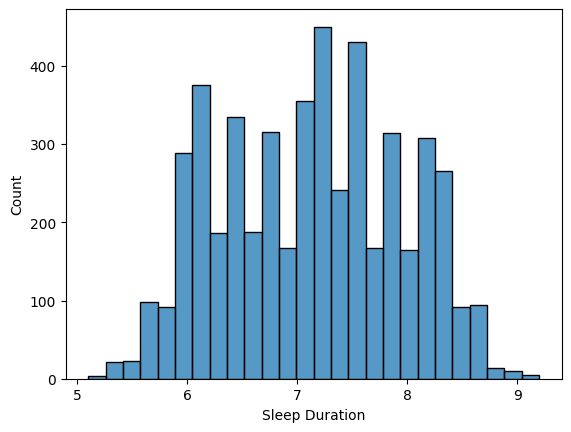

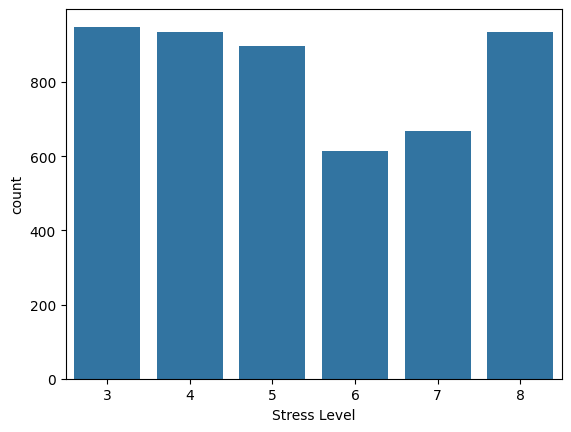

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Sleep Duration"])
plt.show()

sns.countplot(x="Stress Level", data=df)
plt.show()

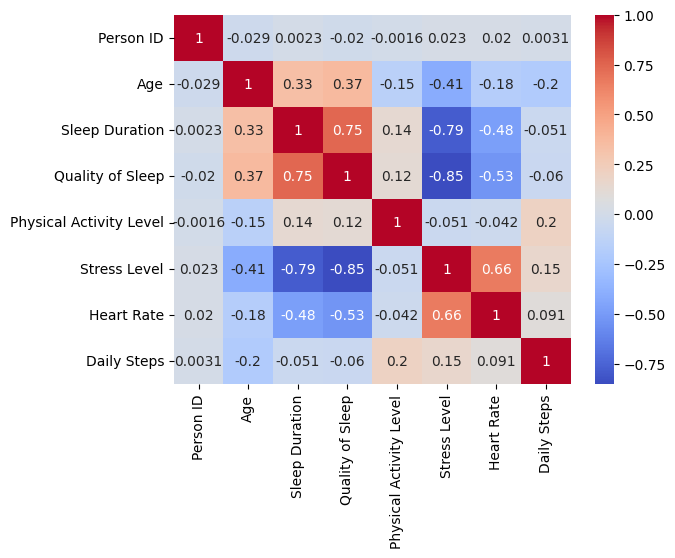

In [7]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [8]:
# Split Blood Pressure
df[["Systolic", "Diastolic"]] = df["Blood Pressure"].str.split("/", expand=True).astype(int)

# Create new feature
df["Pulse Pressure"] = df["Systolic"] - df["Diastolic"]

# Drop useless columns
df.drop(columns=["Blood Pressure", "Person ID"], inplace=True)

In [9]:
df.dropna(inplace=True)

In [11]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include=["object", "string"]).columns

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [12]:
X = df.drop("Stress Level", axis=1)
y = df["Stress Level"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9858823529411764

Classification Report:
               precision    recall  f1-score   support

           3       1.00      1.00      1.00        85
           4       0.96      1.00      0.98        77
           5       0.96      0.96      0.96        27
           6       1.00      0.50      0.67         8
           7       0.98      1.00      0.99       126
           8       1.00      0.99      1.00       102

    accuracy                           0.99       425
   macro avg       0.98      0.91      0.93       425
weighted avg       0.99      0.99      0.98       425


Confusion Matrix:
 [[ 85   0   0   0   0   0]
 [  0  77   0   0   0   0]
 [  0   1  26   0   0   0]
 [  0   2   1   4   1   0]
 [  0   0   0   0 126   0]
 [  0   0   0   0   1 101]]


In [17]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), params, cv=3)
grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

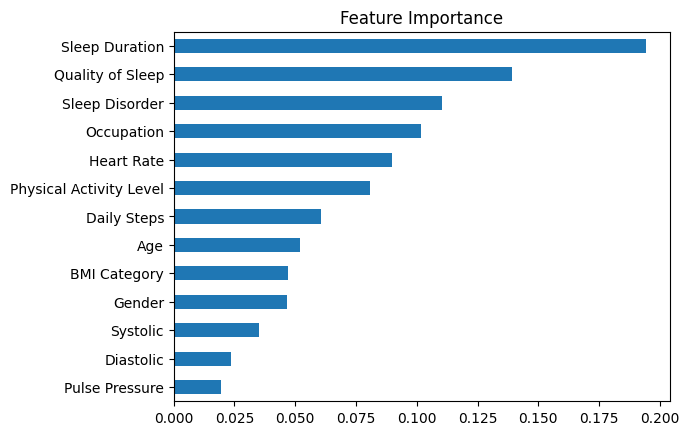

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(best_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [19]:
import joblib

joblib.dump(best_model, "stress_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']